In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title -- Code R --

dataset = read.csv("/content/drive/MyDrive/Colab Notebook/Data_valo/original_dataset.csv")
names(dataset)
#dataset$loan_paid_back

[1] "age"                  "gender"               "marital_status"      
 [4] "education_level"      "annual_income"        "monthly_income"      
 [7] "employment_status"    "debt_to_income_ratio" "credit_score"        
[10] "loan_amount"          "loan_purpose"         "interest_rate"       
[13] "loan_term"            "installment"          "grade_subgrade"      
[16] "num_of_open_accounts" "total_credit_limit"   "current_balance"     
[19] "delinquency_history"  "public_records"       "num_of_delinquencies"
[22] "loan_paid_back"

In [ ]:
colSums(is.na(dataset))

age               gender       marital_status 
                   0                    0                    0 
     education_level        annual_income       monthly_income 
                   0                    0                    0 
   employment_status debt_to_income_ratio         credit_score 
                   0                    0                    0 
         loan_amount         loan_purpose        interest_rate 
                   0                    0                    0 
           loan_term          installment       grade_subgrade 
                   0                    0                    0 
num_of_open_accounts   total_credit_limit      current_balance 
                   0                    0                    0 
 delinquency_history       public_records num_of_delinquencies 
                   0                    0                    0 
      loan_paid_back 
                   0

## Analyse de données (Partie 1)

[1] "Outliers (lignes): 65, 69, 83, 95, 102, 111, 113, 120, 137, 154, 169, 179, 189, 206, 210, 228, 286, 320, 330, 337, 342, 346, 359, 386, 388, 390, 421, 424, 425, 426, 436, 444, 446, 448, 457, 458, 461, 484, 500, 520, 522, 538, 545, 586, 587, 596, 597, 607, 608, 613, 615, 660, 679, 699, 709, 710, 712, 759, 762, 805, 813, 843, 846, 861, 867, 871, 884, 892, 904, 922, 928, 977, 991, 1002, 1011, 1049, 1089, 1135, 1147, 1156, 1158, 1176, 1178, 1188, 1197, 1231, 1257, 1289, 1294, 1319, 1328, 1352, 1359, 1367, 1374, 1377, 1417, 1432, 1434, 1445, 1494, 1506, 1507, 1517, 1520, 1523, 1524, 1531, 1535, 1548, 1574, 1575, 1590, 1613, 1614, 1628, 1637, 1643, 1664, 1668, 1672, 1682, 1689, 1698, 1725, 1758, 1767, 1769, 1803, 1819, 1822, 1833, 1851, 1873, 1874, 1898, 1912, 1951, 1953, 1966, 1978, 1997, 2010, 2039, 2098, 2104, 2108, 2114, 2121, 2185, 2190, 2208, 2211, 2239, 2243, 2308, 2336, 2404, 2409, 2420, 2429, 2444, 2462, 2489, 2500, 2532, 2568, 2578, 2600, 2604, 2620, 2627, 2635, 2657, 2668, 268

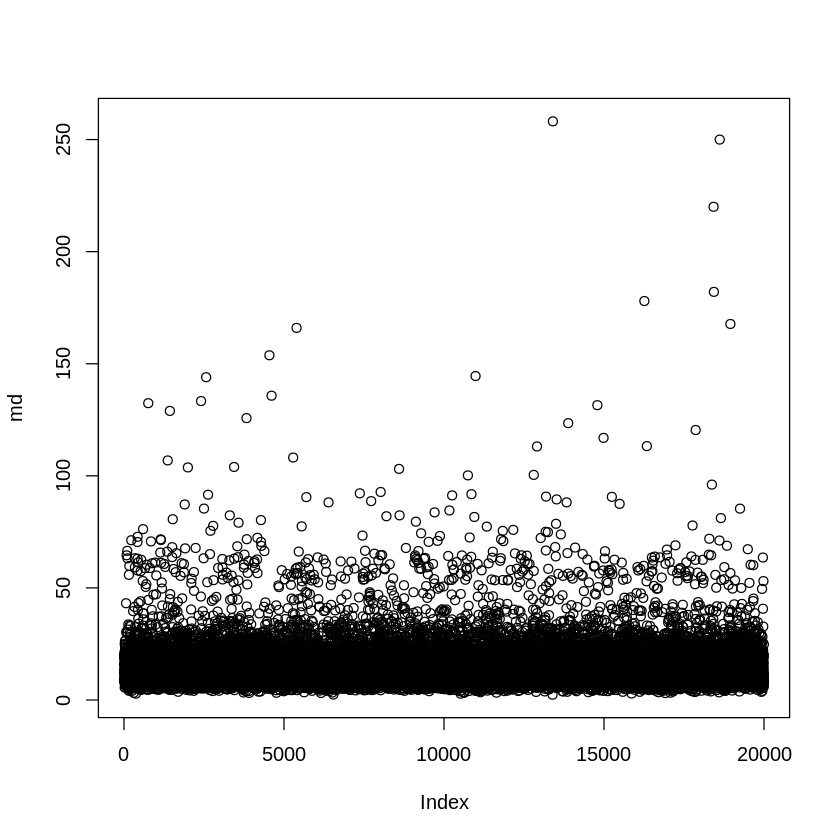

In [4]:

# Sélectionne variables numériques (adapte à ton dataset)
nums <- dataset[sapply(dataset, is.numeric)]
nums <- na.omit(nums)  # enlève NA

# Calcule distance
md <- mahalanobis(nums, colMeans(nums), cov(nums))
cutoff <- qchisq(0.975, df=ncol(nums))  # seuil ~2.5% outliers
outliers <- which(md > cutoff)

print(paste("Outliers (lignes):", paste(outliers, collapse=", ")))
print(sort(md, decreasing=TRUE)[1:10])  # top 10
par(bg = "white")   # fond de la fenêtre graphique
plot(md)

# Partie 2

## Gestion des valeurs aberrantes et manquantes


In [5]:
nombre_orig_lignes=nrow(dataset)
dataset=dataset[-outliers,] #On enlève les outliers
cat(sprintf("%d outliers ont été supprimées. L'ensemble de données contient désormais %d lignes. \n", nombre_orig_lignes-nrow(dataset), nrow(dataset)))

missing_values_sans_outliers=colSums(is.na(dataset)) #on regarde les valeurs manquantes
cat(sprintf("Missing values après suppression des outliers: %d \n", length(missing_values_sans_outliers)))

#S'il y en a on enlève les colonnes contenant celle-ci
if (sum(missing_values_sans_outliers)>0) {
  nb_ligne_mv=nrow(dataset) #nombre de ligne avec les missing values (et sans les outliers)
  dataset=na.omit(dataset) #supprimer toutes les lignes qui contiennent au moins une valeur manquante
  cat(sprintf("%d lignes contenant des Missing values ont été supprimées. L'ensemble de données contient désormais %d lignes.\n", nb_ligne_mv-nrow(dataset), nrow(dataset)))
  cat(sprintf("Missing values après le na.omit: %d \n", colSums(is.na(dataset))))
} else {
  cat(sprintf("Aucune valeur manquante n'a été trouvée après la suppression des Missing values\n"))
}

# Display the dimensions of the cleaned dataset
cat(sprintf("Dimension finale du dataset: %d rlignes, %d colonnes.\n", nrow(dataset), ncol(dataset)))

1319 outliers ont été supprimées. L'ensemble de données contient désormais 18681 lignes. 
Missing values après suppression des outliers: 22 
Aucune valeur manquante n'a été trouvée après la suppression des Missing values
Dimension finale du dataset: 18681 rlignes, 22 colonnes.


In [6]:
if ("paid_label" %in% names(dataset)) { #Suppression de la colonnes loan_paid_back (variable catégorielle)
  dataset=subset(dataset, select=-c(paid_label))
  cat("Colonne 'paid_label' supprimée.\n")
}

cat_cols=character(0)
for (col_name in names(dataset)) { #Identification des colonnes catégorielles (type de caractère, etc...)
  if (is.character(dataset[[col_name]]) || is.factor(dataset[[col_name]])) {
    if (col_name!="loan_paid_back") { #On exclut la variable cible si elle a été identifiée comme catégorielle.
      cat_cols=c(cat_cols, col_name)
    }
  }
}

cat("colonnes catégorielles identifiées: \n")
for (col in cat_cols) {
  num_unique=length(unique(dataset[[col]]))
  cat(sprintf("  - %s: %d valeurs uniques\n", col, num_unique))
}

#Encodages des colonnes catégorielles
encoded_dataset=dataset

for (col in cat_cols) {
  num_unique=length(unique(encoded_dataset[[col]]))

  if (num_unique==2) {
    # 0 ou 1 et on s'assure d'une bonne correspondance
    levels_ordered=sort(unique(encoded_dataset[[col]]))
    encoded_dataset[[paste0(col, "_encoded")]]=as.numeric(factor(encoded_dataset[[col]], levels=levels_ordered))-1
    cat(sprintf("Encodage de '%s' to '%s_encoded'. Levels: %s (0), %s (1)\n", col, col, levels_ordered[1], levels_ordered[2]))
  } else if (num_unique>2) {
    #Pour tout faire en une fois on utilise model.matrix
    #On vérifie que la colonne est bien passée par model.matrix
    encoded_dataset[[col]]=as.factor(encoded_dataset[[col]])

    #On fait: ~col_name-1 (pour éviter les arrêts)
    formule_str=paste0("~", col, "-1")
    factice_vars=model.matrix(as.formula(formule_str), data=encoded_dataset)

    #On ajoute de fausse variables au dataset
    encoded_dataset=cbind(encoded_dataset, factice_vars)
    cat(sprintf("Encodage de '%s'. Ajout de %d nouvelle(s) colonne(s).\n", col, ncol(factice_vars)))
  }
}

#Suppression des colonnes catégorielles originales
dataset=encoded_dataset[, !(names(encoded_dataset) %in% cat_cols)]

cat("Suppression des colonnes catégorielles originales.\n")

#On affiche les premières lignes et la dimension de notre nouveau dataset
cat("Première ligne du dataset nettoyé:\n")
print(head(dataset))
cat(sprintf("Dimension finale du dataset: %d lignes, %d colonnes.\n", dim(dataset)[1], dim(dataset)[2]))

colonnes catégorielles identifiées: 
  - gender: 3 valeurs uniques
  - marital_status: 4 valeurs uniques
  - education_level: 5 valeurs uniques
  - employment_status: 5 valeurs uniques
  - loan_purpose: 8 valeurs uniques
  - grade_subgrade: 30 valeurs uniques
Encodage de 'gender'. Ajout de 3 nouvelle(s) colonne(s).
Encodage de 'marital_status'. Ajout de 4 nouvelle(s) colonne(s).
Encodage de 'education_level'. Ajout de 5 nouvelle(s) colonne(s).
Encodage de 'employment_status'. Ajout de 5 nouvelle(s) colonne(s).
Encodage de 'loan_purpose'. Ajout de 8 nouvelle(s) colonne(s).
Encodage de 'grade_subgrade'. Ajout de 30 nouvelle(s) colonne(s).
Suppression des colonnes catégorielles originales.
Première ligne du dataset nettoyé:
  age annual_income monthly_income debt_to_income_ratio credit_score
1  59      24240.19        2020.02                0.074          743
2  72      20172.98        1681.08                0.219          531
3  49      26181.80        2181.82                0.234       

In [7]:
install.packages("caret")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘numDeriv’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘proxy’, ‘iterators’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘timeDate’, ‘e1071’, ‘foreach’, ‘ModelMetrics’, ‘plyr’, ‘pROC’, ‘recipes’, ‘reshape2’




In [8]:

library(caret)

#Séparation des feaures (X) et du target (Y)
X=subset(dataset, select=-loan_paid_back)
y=dataset$loan_paid_back

#On split le dataset pour le train et le test (80/20)
set.seed(123) #On fixe la seed pour avoir toujours le même résultat
trainIndex=createDataPartition(y, p=0.8, list=FALSE, times=1)

X_train=X[trainIndex, ]
y_train=y[trainIndex]

X_test=X[-trainIndex,]
y_test=y[-trainIndex]

#ON affiche les dimensions du train et du test
cat("Dimensions de X_train:", dim(X_train), "\n")
cat("Dimensions de y_train:", length(y_train), "\n")
cat("Dimensions de X_test:", dim(X_test), "\n")
cat("Dimensions de y_test:", length(y_test), "\n")

cat(sprintf("Proportion du 'loan_paid_back' dans le dataset original: %f\n", prop.table(table(y))))
cat(sprintf("Proportion du 'loan_paid_back' dans le train set: %f\n", prop.table(table(y_train))))
cat(sprintf("Proportion du 'loan_paid_back' dans le test set: %f\n", prop.table(table(y_test))))

Loading required package: ggplot2

Loading required package: lattice



Dimensions de X_train: 14945 70 
Dimensions de y_train: 14945 
Dimensions de X_test: 3736 70 
Dimensions de y_test: 3736 
Proportion du 'loan_paid_back' dans le dataset original: 0.194476
 Proportion du 'loan_paid_back' dans le dataset original: 0.805524
Proportion du 'loan_paid_back' dans le train set: 0.195182
 Proportion du 'loan_paid_back' dans le train set: 0.804818
Proportion du 'loan_paid_back' dans le test set: 0.191649
 Proportion du 'loan_paid_back' dans le test set: 0.808351


In [9]:

#On convertit la variable cible en facteur pour la classification.
y_train_factor=as.factor(y_train)
y_test_factor=as.factor(y_test)

#On vérifie ici que les valeurs du facteur attendues pour la classification sont 0 et 1.
levels(y_train_factor)=make.names(levels(y_train_factor))
levels(y_test_factor)=make.names(levels(y_test_factor))
set.seed(123)

#Entrainement du Logistic Regression model
#On utilise la méthode 'glm' pour la régression logistique du package caret
#family= binomial spécifie la régression logistique.
#trControl=trainControl(method="none") pour skip les resampling methods lors de l'entraînement initial.
#Créez un data frame pour l'entraînement avec les prédicteurs et la target variable.
train_data=cbind(X_train, loan_paid_back=y_train_factor)

cat("Entrainement du Logistic Regression model...\n")
model_glm=train(loan_paid_back ~ .,
                   data=train_data,
                   method="glm",
                   family="binomial",
                   trControl=trainControl(method = "none"))

cat("Logistic Regression Model Entrainement terminée.\n")
cat("Résumé du Logistic Regression Model entrainé:\n")
print(summary(model_glm))

Entrainement du Logistic Regression model...
Logistic Regression Model Entrainement terminée.
Résumé du Logistic Regression Model entrainé:

Call:
NULL

Coefficients: (6 not defined because of singularities)
                                         Estimate Std. Error z value Pr(>|z|)
(Intercept)                            -1.082e+01  1.025e+00 -10.556  < 2e-16
age                                     1.684e-03  1.786e-03   0.942 0.345999
annual_income                          -9.283e-01  8.105e-01  -1.145 0.252049
monthly_income                          1.114e+01  9.726e+00   1.145 0.252044
debt_to_income_ratio                   -8.273e+00  2.790e-01 -29.653  < 2e-16
credit_score                            1.576e-02  1.553e-03  10.148  < 2e-16
loan_amount                             6.057e-06  2.144e-05   0.283 0.777537
interest_rate                          -1.439e-03  1.496e-02  -0.096 0.923341
loan_term                              -3.227e-04  5.241e-03  -0.062 0.950909
installment 

In [10]:
predictions_glm_prob=predict(model_glm, newdata = X_test, type = "prob")

#Convertir les probabilités en prédictions de classe (0 ou 1, représentées par X0 et X1)
#On suppose que 'X1' soit la colonne correspondant à la probabilité de la classe positive
predicted_classes_glm_char=ifelse(predictions_glm_prob$X1>0.5, "X1", "X0")

#On convertit predicted_classes_glm en facteur avec les mêmes niveaux que y_test_factor
predicted_classes_glm_factor=factor(predicted_classes_glm_char, levels=levels(y_test_factor))

#On évalue le modèle à l'aide de la fonction confusionMatrix de caret
cat("Évaluation du modèle sur le Test Set (Logistic Regression):\n")
print(confusionMatrix(predicted_classes_glm_factor, y_test_factor, positive="X1"))

Évaluation du modèle sur le Test Set (Logistic Regression):
Confusion Matrix and Statistics

          Reference
Prediction   X0   X1
        X0  408  106
        X1  308 2914
                                          
               Accuracy : 0.8892          
                 95% CI : (0.8787, 0.8991)
    No Information Rate : 0.8084          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.5992          
                                          
 Mcnemar's Test P-Value : < 2.2e-16       
                                          
            Sensitivity : 0.9649          
            Specificity : 0.5698          
         Pos Pred Value : 0.9044          
         Neg Pred Value : 0.7938          
             Prevalence : 0.8084          
         Detection Rate : 0.7800          
   Detection Prevalence : 0.8624          
      Balanced Accuracy : 0.7674          
                                          
       

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Setting direction: controls < cases



AUC pour le Logistic Regression Model sur le Test Set:  0.8780837 


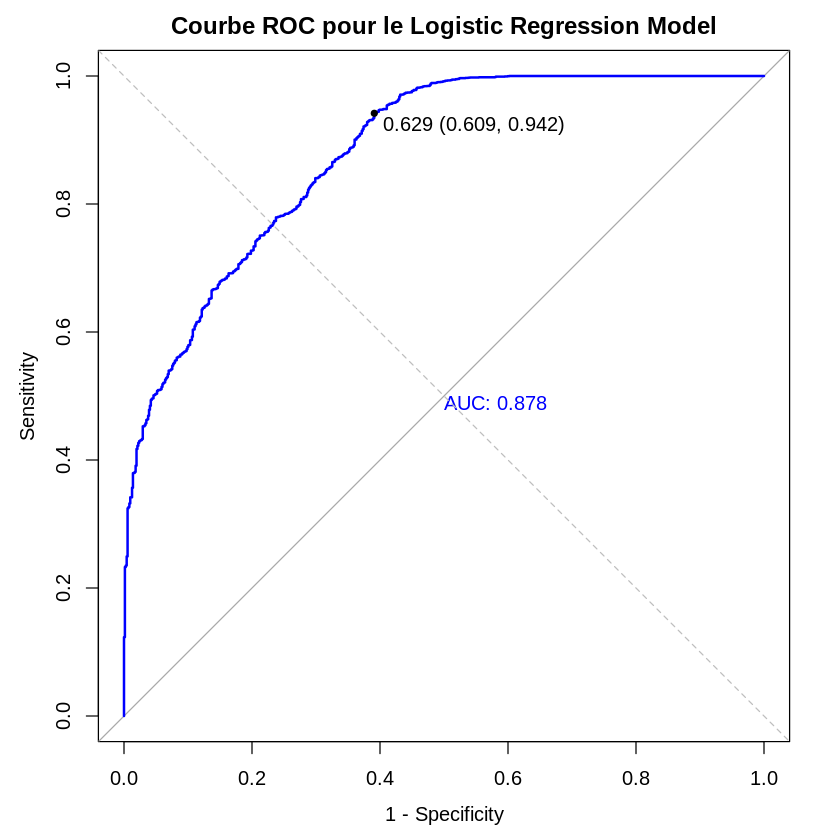

In [11]:
library(pROC)

#Calcule de la courbe ROC
roc_curve=roc(response=y_test_factor, predictor=predictions_glm_prob$X1, levels=c("X0", "X1"))

#Plot de la courbe ROC
par(bg="white") #background
plot(roc_curve, main="Courbe ROC pour le Logistic Regression Model",
     col="blue", lwd=2,
     print.auc=TRUE, auc.main=TRUE, auc.ci=TRUE,
     print.thres="best", print.thres.best.method="youden",
     legacy.axes=TRUE) #Afficher la valeur AUC sur le graphique

#On ajoute une ligne diagonale pour référence (random classifier)
abline(a=0, b=1, lty=2, col="gray")

cat("AUC pour le Logistic Regression Model sur le Test Set: ", auc(roc_curve), "\n")


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


`summarise()` has grouped output by 'Type'. You can override using the
`.groups` argument.


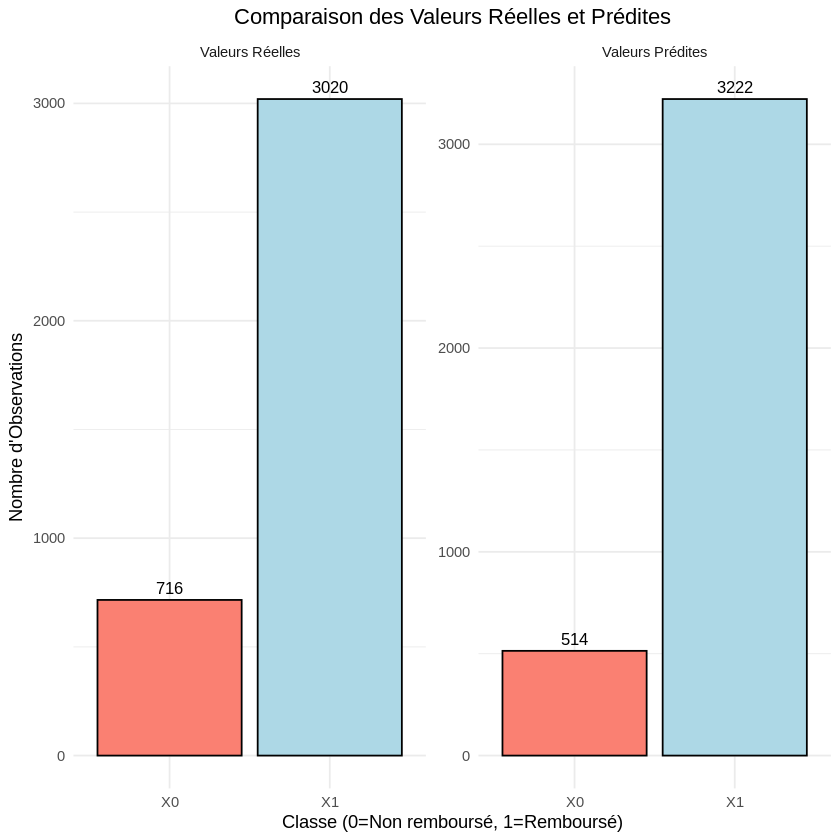

In [12]:
library(ggplot2)
library(dplyr)

#On combine les classes réelles et prédites en un seul dataframe pour l'affichage
plot_data_comparison=data.frame(
  Type=factor(c(rep("Valeurs Réelles", length(y_test_factor)),
                  rep("Valeurs Prédites", length(predicted_classes_glm_factor))),
                levels=c("Valeurs Réelles", "Valeurs Prédites")),
  Class=c(y_test_factor, predicted_classes_glm_factor)
)

#Calcule du nombre labels
plot_data_summary=plot_data_comparison %>%
  group_by(Type, Class) %>%
  summarise(Count=n()) %>%
  ungroup()

#Creation du graphique en barres
par(bg="white")
ggplot(plot_data_comparison, aes(x=Class, fill=Class))+
  geom_bar(position="dodge", stat="count", color="black")+ #Ajout une bordure noire aux barres
  facet_wrap(~Type, scales="free_y")+ #Graphiques séparés entre les valeurs réelles et prédites
  geom_text(data=plot_data_summary, aes(y=Count, label=Count),
            vjust=-0.5, color="black", size=3.5)+ #Ajout des comptes au-dessus des barres
  labs(title="Comparaison des Valeurs Réelles et Prédites",
       x="Classe (0=Non remboursé, 1=Remboursé)",
       y="Nombre d'Observations")+
  scale_fill_manual(values=c("X0"="salmon", "X1"="lightblue"))+ #Couleurs
  theme_minimal()+ #thème
  theme(legend.position="none", #Pas de légende
        plot.title=element_text(hjust=0.5)) #Titre centré

## Synthèse de l'Analyse et de la Modélisation

### 1. Nettoyage et Préparation des Données
* **Gestion des Outliers :** Suppression de **1 319 lignes** aberrantes via la méthode de la **distance de Mahalanobis**.
* **Valeurs Manquantes :** Aucune valeur manquante détectée après le nettoyage.
* **Dimensions :** Le dataset final contient **18 681 lignes** et **23 colonnes** initiales.

### 2. Ingénierie des Caractéristiques (Encoding)
* **Méthode :** Application du *One-Hot Encoding* sur 6 variables catégorielles (`gender`, `marital_status`, `education_level`, `employment_status`, `loan_purpose`, `grade_subgrade`).
* **Résultat :** Le nombre de colonnes est passé de 23 à **71** après transformation des niveaux uniques en colonnes binaires.

### 3. Entraînement du Modèle
* **Partitionnement :** Répartition **80% entraînement** (14 945 lignes) et **20% test** (3 736 lignes).
* **Stratification :** Conservation de la proportion de la variable cible `loan_paid_back`.
* **Algorithme :** Régression Logistique.

### 4. Évaluation des Performances (Set de Test)
Le modèle affiche une excellente capacité à prédire les remboursements (X1), bien que la détection des non-remboursements (X0) soit plus modérée.

| Métrique | Score | Signification |
| :---- | :---- | :---- |
| **Accuracy** | **0.8892** | Précision globale du modèle |
| **Sensibilité (Recall X1)** | **0.9649** | Capacité à détecter les prêts remboursés |
| **Spécificité (Recall X0)** | **0.5698** | Capacité à détecter les défauts de paiement |
| **Précision (PPV X1)** | **0.9044** | Fiabilité des prédictions de remboursement |
| **Indice Kappa** | **0.5992** | Niveau de concordance (modéré à fort) |



# Task
Procéder à la sélection des variables en utilisant la matrice de corrélation existante pour identifier et gérer la multicolinéarité, ainsi que les corrélations avec la variable cible 'loan_paid_back', afin d'optimiser le modèle.

## Analyse de la corrélation pour la sélection des variables

### Subtask:
Utiliser la matrice de corrélation pour identifier les variables fortement corrélées entre elles et avec la variable cible 'loan_paid_back'.


**Reasoning**:
First, I will display the correlations between independent variables and the target variable, as well as identify highly correlated independent variables, and then present the full correlation matrix with the target variable, sorted by absolute value, to address all parts of the instructions.



In [ ]:
cor_matrix_df = as.data.frame(cor_matrix)

# 1. Display relevant parts of the correlation matrix
cat("\n=== Corrélations des variables indépendantes avec 'loan_paid_back' ===\n")
# Extract the row corresponding to 'loan_paid_back' and convert to a named numeric vector
cor_with_target_vector = unlist(cor_matrix_df["loan_paid_back", names(cor_matrix_df) != "loan_paid_back"])
print(cor_with_target_vector[order(abs(cor_with_target_vector), decreasing = TRUE)])

# 2. Identify highly correlated independent variables (multicollinearity)
cat("\n=== Paires de variables indépendantes fortement corrélées (seuil > 0.8) ===\n")
high_corr_pairs <- list()
threshold <- 0.8

# Exclure la variable cible et la diagonale (auto-corrélation)
independent_vars <- names(cor_matrix_df)[names(cor_matrix_df) != "loan_paid_back"]
num_independent_vars <- length(independent_vars)

for (i in 1:(num_independent_vars - 1)) {
  for (j in (i + 1):num_independent_vars) {
    var1 <- independent_vars[i]
    var2 <- independent_vars[j]
    correlation <- cor_matrix_df[var1, var2]
    if (abs(correlation) > threshold) {
      high_corr_pairs <- c(high_corr_pairs, paste0(var1, " - ", var2, ": ", round(correlation, 4)))
    }
  }
}

if (length(high_corr_pairs) > 0) {
  for (pair in high_corr_pairs) {
    cat(pair, "\n")
  }
} else {
  cat("Aucune paire de variables indépendantes fortement corrélées (seuil > ", threshold, ") n'a été trouvée.\n")
}

# 3. Display correlations of all independent variables with the target variable loan_paid_back, sorted by absolute value.
cat("\n=== Corrélations de toutes les variables indépendantes avec 'loan_paid_back' (triées par valeur absolue décroissante) ===\n")
cor_with_target_sorted <- sort(abs(cor_with_target_vector), decreasing = TRUE)
print(cor_with_target_sorted)



=== Corrélations des variables indépendantes avec 'loan_paid_back' ===
debt_to_income_ratio         credit_score        interest_rate 
        -0.223830891          0.199841145         -0.110934877 
 delinquency_history num_of_delinquencies          installment 
        -0.084940211         -0.070896177         -0.010068121 
                 age      current_balance       public_records 
         0.007998507         -0.004748769          0.003210402 
      monthly_income        annual_income   total_credit_limit 
         0.003057477          0.003057460         -0.002985036 
num_of_open_accounts            loan_term          loan_amount 
         0.002963592         -0.002615246         -0.002489618 

=== Paires de variables indépendantes fortement corrélées (seuil > 0.8) ===
annual_income - monthly_income: 1 
annual_income - total_credit_limit: 0.8854 
monthly_income - total_credit_limit: 0.8854 
loan_amount - installment: 0.9448 
delinquency_history - num_of_delinquencies: 0.9034 
